#Brain Tumor Classification new way

In [1]:
# Import necessary libraries
from tensorflow.keras.layers import Input, Dropout, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import itertools
import cv2
import os
import io

2024-05-11 07:51:39.888835: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-11 07:51:39.888975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-11 07:51:40.024453: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Define directories where training and testing data are located
Train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
Test_dir = "/kaggle/input/brain-tumor-mri-dataset/Testing"


**Total number of images in dataset**

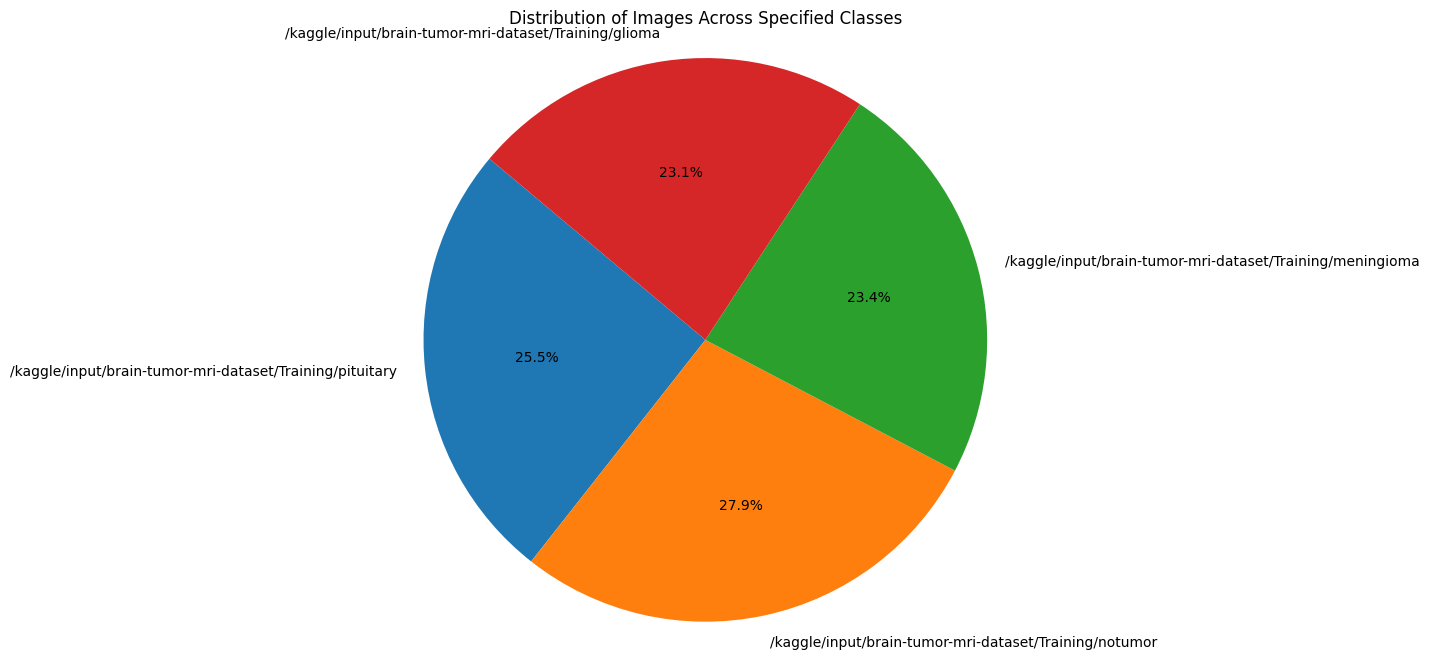

Total number of images: 5712


In [9]:
import os
import matplotlib.pyplot as plt

# Initialize variables
total_images = 0  # Counter for total number of images
directory_counts = {}  # Dictionary to store counts of images in each directory

# Specify the four classes you want to include
classes_to_include = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Walk through directories and count images for specified classes
for dirpath, dirnames, filenames in os.walk("/kaggle/input/brain-tumor-mri-dataset/Training"):
    # Check if the current directory belongs to one of the specified classes
    if any(className in dirpath for className in classes_to_include):
        # Count the number of images in the current directory and store in the dictionary
        directory_counts[dirpath] = len(filenames)
        # Update total number of images
        total_images += len(filenames)

# Plotting
plt.figure(figsize=(8, 8))  # Set the size of the plot
plt.pie(directory_counts.values(), labels=directory_counts.keys(), autopct='%1.1f%%', startangle=140)
# Create a pie chart with counts of images in each directory
plt.title('Distribution of Images Across Specified Classes')  # Set the title of the plot
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()  # Display the plot

print("Total number of images:", total_images)  # Print total number of images


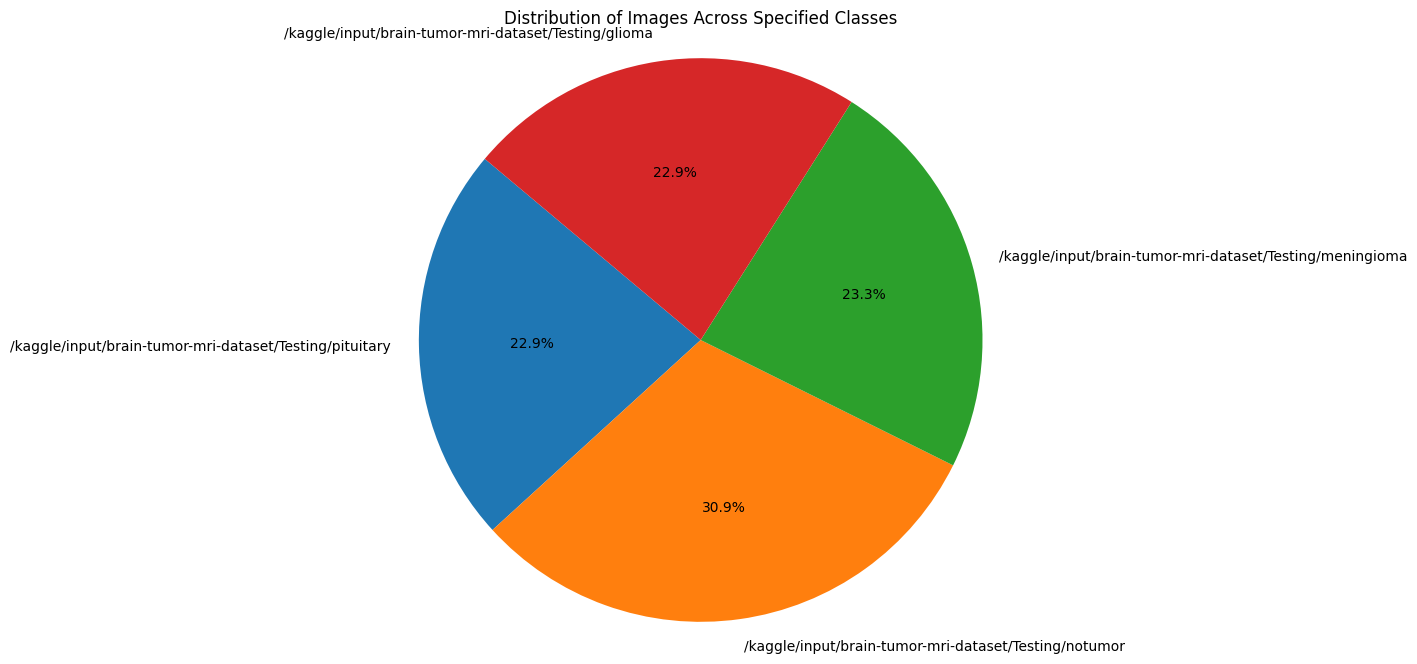

Total number of images: 1311


In [10]:
import os
import matplotlib.pyplot as plt

# Initialize variables
total_images = 0  # Counter for total number of images
directory_counts = {}  # Dictionary to store counts of images in each directory

# Specify the four classes you want to include
classes_to_include = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Walk through directories and count images for specified classes
for dirpath, dirnames, filenames in os.walk("/kaggle/input/brain-tumor-mri-dataset/Testing"):
    # Check if the current directory belongs to one of the specified classes
    if any(className in dirpath for className in classes_to_include):
        # Count the number of images in the current directory and store in the dictionary
        directory_counts[dirpath] = len(filenames)
        # Update total number of images
        total_images += len(filenames)

# Plotting
plt.figure(figsize=(8, 8))  # Set the size of the plot
plt.pie(directory_counts.values(), labels=directory_counts.keys(), autopct='%1.1f%%', startangle=140)
# Create a pie chart with counts of images in each directory
plt.title('Distribution of Images Across Specified Classes')  # Set the title of the plot
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()  # Display the plot

print("Total number of images:", total_images)  # Print total number of images


**Check for corrupter image**

In [11]:
# Function to check for image corruption
def is_corrupted(image):

#     Checks if an image is corrupted.
#     Parameters:
#     - image: NumPy array representing the image.
#     Returns:
#     - True if the image is corrupted (None or contains NaN values), False otherwise.
    # Check if the image is None or contains any NaN values
    return image is None or np.any(np.isnan(image))


In [12]:
# List of labels for the classes
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Initialize lists to store training and testing images and labels
x_train = []  # training images
y_train = []  # training labels
x_test = []   # testing images
y_test = []   # testing labels

# Size to which images will be resized
image_size = 200

# Loop through each label
for label in labels:
    # Paths to training and testing directories for the current label
    trainPath = os.path.join(Train_dir, label)
    testPath = os.path.join(Test_dir, label)
    
    # Load and preprocess training images
    for file in tqdm(os.listdir(trainPath)):
        image = cv2.imread(os.path.join(trainPath, file), 0)  # Load images in grayscale
        image = cv2.bilateralFilter(image, 2, 50, 50)         # Remove image noise
        image = cv2.applyColorMap(image, cv2.COLORMAP_BONE)   # Produce a pseudocolored image
        image = cv2.resize(image, (image_size, image_size))   # Resize images
        x_train.append(image)                                # Append image to x_train list
        y_train.append(labels.index(label))                  # Append label index to y_train list
        
        # Check for corrupted images
        if is_corrupted(image):
            print("Corrupted image found:", os.path.join(trainPath, file))

    # Load and preprocess testing images
    for file in tqdm(os.listdir(testPath)):
        image = cv2.imread(os.path.join(testPath, file), 0)   # Load images in grayscale
        image = cv2.bilateralFilter(image, 2, 50, 50)         # Remove image noise
        image = cv2.applyColorMap(image, cv2.COLORMAP_BONE)   # Produce a pseudocolored image
        image = cv2.resize(image, (image_size, image_size))   # Resize images
        x_test.append(image)                                 # Append image to x_test list
        y_test.append(labels.index(label))                   # Append label index to y_test list
        
        # Check for corrupted images
        if is_corrupted(image):
            print("Corrupted image found:", os.path.join(testPath, file))

# Convert lists to NumPy arrays and normalize pixel values to range [0, 1]
x_train = np.array(x_train) / 255.0
x_test = np.array(x_test) / 255.0

# Print the shape of training and testing data arrays
print(x_train.shape)
print(x_test.shape)


100%|██████████| 300/300 [00:03<00:00, 96.43it/s] 


(5712, 200, 200, 3)
(1311, 200, 200, 3)


**display image from each class**

In [ ]:
# Select the first 15 images from the training dataset
images = [x_train[i] for i in range(15)]

# Create subplots grid with 3 rows and 5 columns
fig, axes = plt.subplots(3, 5, figsize=(10, 10))

# Flatten the axes array to iterate through each subplot
axes = axes.flatten()

# Iterate through each image and subplot, and display the image
for img, ax in zip(images, axes):
    ax.imshow(img, cmap='gray')  # Display the image in grayscale
    ax.axis('off')                # Turn off axes for better visualization

# Adjust layout to prevent overlapping of subplots
plt.tight_layout()

# Display the plot
plt.show()


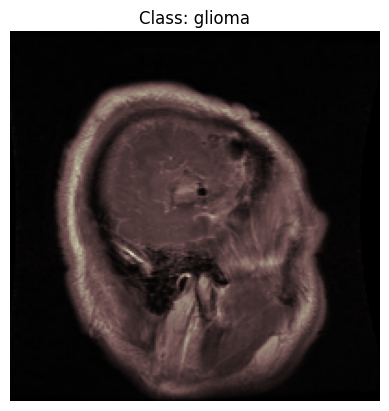

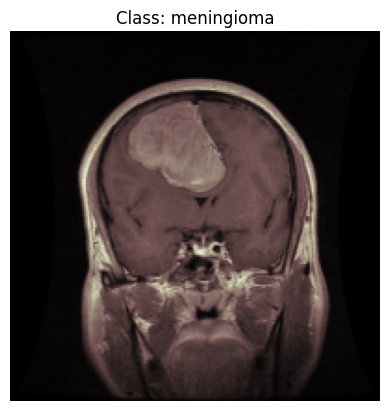

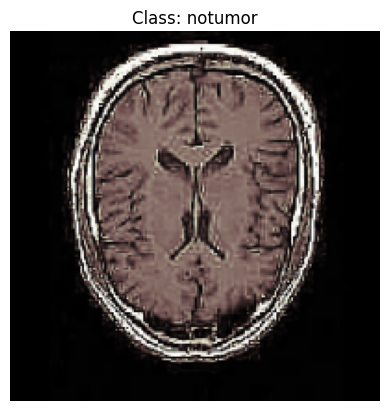

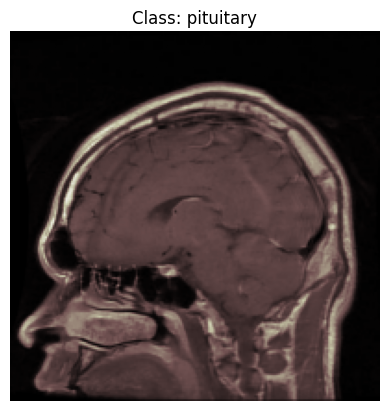

In [15]:
import matplotlib.pyplot as plt

# Visualize an image from each class
for label in labels:
    # Find the index of the first image in the current class
    index = y_train.index(labels.index(label))

    # Get the corresponding image
    sample_image = x_train[index]

    # Display the image
    plt.figure()                                  # Create a new figure
    plt.imshow(sample_image, cmap='gray')         # Display the image in grayscale
    plt.title('Class: {}'.format(label))          # Set the title of the plot
    plt.axis('off')                               # Turn off axes for better visualization
    plt.show()                                    # Show the plot


**split data into train test and change into categorical values**

In [16]:
# Shuffle the training data and labels with a fixed random state
x_train, y_train = shuffle(x_train, y_train, random_state=42)

# Convert the training and testing labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train)  # Training labels
y_test = tf.keras.utils.to_categorical(y_test)    # Testing labels

# Split the training data and labels into training and validation sets
# Validation set size is 20% of the training set
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Print the shape of the validation set
print(x_val.shape)


(1143, 200, 200, 3)


In [17]:
# ImageDataGenerator to perform data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,             # Degree range for random rotations
    width_shift_range=0.05,        # Fraction of total width for random horizontal shifts
    height_shift_range=0.05,       # Fraction of total height for random vertical shifts
    zoom_range=[0.5, 1.5],         # Range for random zoom
    horizontal_flip=True          # Randomly flip inputs horizontally
)

# Fit the ImageDataGenerator on the training data
datagen.fit(x_train)


**viswalizing agumented images**

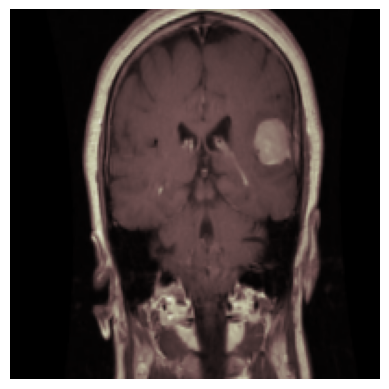

In [18]:
# Generate augmented images
augmented_images = datagen.flow(x_train, batch_size=1)

# Get the first augmented image batch
augmented_image_batch = augmented_images.next()

# Get the augmented image from the batch
augmented_image = augmented_image_batch[0][0]

# Display the augmented image
plt.imshow(augmented_image, cmap='gray')  # Assuming images are grayscale
plt.axis('off')
plt.show()


**using-transfer_learning**

In [19]:
from tensorflow.keras.applications import ResNet50

# Create a ResNet50 model
net = ResNet50(
    weights='imagenet',   # Load weights pre-trained on ImageNet
    include_top=False,    # Do not include the ImageNet classifier at the top
    input_shape=(200, 200, 3)  # Define the input shape of the model (200x200 pixels with 3 color channels)
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [20]:
# Get the output tensor from the ResNet50 base model
model = net.output

# Add a GlobalAveragePooling2D layer to reduce spatial dimensions and aggregate features
model = GlobalAveragePooling2D()(model)

# Add a Dropout layer to prevent overfitting by randomly setting a fraction of input units to 0
model = Dropout(0.4)(model)

# Add a Dense layer with softmax activation for classification
# The output dimension is set to 4 because there are 4 classes
model = Dense(4, activation="softmax")(model)

# Create a new model with ResNet50 as the base and the added layers for classification
model = Model(inputs=net.input, outputs=model)

# Compile the model with specified optimizer, loss function, and evaluation metrics
adam = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary to display model architecture and number of parameters
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 206, 206,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 100, 100,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 100, 100,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 100, 100,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 102, 102,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 50, 50,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 50, 50,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 50, 50,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 50, 50,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 50, 50,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 50, 50,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 50, 50,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 50, 50,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 50, 50,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_3_c

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 23,542,788 (89.81 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [21]:
# Train the model using data augmentation generator for training data
# and validation data specified by (x_val, y_val)
# The number of epochs is set to 15
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=20),  # Data augmentation generator for training data
    validation_data=(x_val, y_val),                 # Validation data
    epochs=15                                       # Number of epochs
)


Epoch 1/15


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  1/229 ━━━━━━━━━━━━━━━━━━━━ 4:21:48 69s/step - accuracy: 0.3500 - loss: 2.1558

I0000 00:00:1715414443.816318     172 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1715414443.911156     172 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


229/229 ━━━━━━━━━━━━━━━━━━━━ 148s 347ms/step - accuracy: 0.7691 - loss: 0.6122 - val_accuracy: 0.3482 - val_loss: 2.0751
Epoch 2/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 39s 165ms/step - accuracy: 0.9281 - loss: 0.1977 - val_accuracy: 0.2292 - val_loss: 2.5413
Epoch 3/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 39s 164ms/step - accuracy: 0.9457 - loss: 0.1684 - val_accuracy: 0.4059 - val_loss: 2.5528
Epoch 4/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 39s 165ms/step - accuracy: 0.9519 - loss: 0.1284 - val_accuracy: 0.7857 - val_loss: 0.7689
Epoch 5/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 39s 166ms/step - accuracy: 0.9679 - loss: 0.0983 - val_accuracy: 0.9668 - val_loss: 0.1329
Epoch 6/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 39s 167ms/step - accuracy: 0.9717 - loss: 0.0854 - val_accuracy: 0.9545 - val_loss: 0.1528
Epoch 7/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 39s 166ms/step - accuracy: 0.9747 - loss: 0.0697 - val_accuracy: 0.9545 - val_loss: 0.1611
Epoch 8/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 39s 165ms/step - accuracy: 0.9713 - loss: 0.0851 - va

**Using Cnn**

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_cnn_model(input_shape, num_classes=4):
    # Create a Sequential model
    model = models.Sequential()

    # Convolutional layers
    # Add a 2D convolutional layer with 32 filters, each of size (3, 3), ReLU activation, and 'same' padding
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape[1:]))
    # Add a max pooling layer with pool size (2, 2)
    model.add(layers.MaxPooling2D((2, 2)))

    # Add another 2D convolutional layer with 64 filters, each of size (3, 3), and ReLU activation
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    # Add another max pooling layer
    model.add(layers.MaxPooling2D((2, 2)))

    # Add another 2D convolutional layer with 128 filters, each of size (3, 3), and ReLU activation
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    # Add another max pooling layer
    model.add(layers.MaxPooling2D((2, 2)))

    # Add another 2D convolutional layer with 128 filters, each of size (3, 3), and ReLU activation
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    # Add another max pooling layer
    model.add(layers.MaxPooling2D((2, 2)))

    # Flatten layer to convert 3D feature maps to 1D feature vectors
    model.add(layers.Flatten())

    # Dense layers
    # Add a dense layer with 512 units and ReLU activation
    model.add(layers.Dense(512, activation='relu'))
    # Add an output layer with num_classes units and softmax activation for classification
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model



In [23]:
# Define input shape (e.g., image dimensions)
input_shape = (200, 200, 3)  # Specify your image dimensions

# Create the CNN model
model_cnn = create_cnn_model(input_shape)

# Compile the model
model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',  # For integer labels
                  metrics=['accuracy'])

# Print the model summary

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [24]:
model_cnn.summary() # Print the model summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 98, 98, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,796,996 (25.93 MB)

 Trainable params: 6,796,996 (25.93 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train the CNN model using the training data (x_train, y_train)
# The batch size is set to 20, validation data is specified by (x_val, y_val), and the number of epochs is 10
history_cnn = model_cnn.fit(
    x_train, y_train,              # Training data and labels
    batch_size=20,                 # Batch size for training
    validation_data=(x_val, y_val),# Validation data and labels
    epochs=10                      # Number of epochs (complete passes through the training dataset)
)


Epoch 1/10


2024-05-11 08:11:27.383577: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 0: 3.2626, expected 2.34842
2024-05-11 08:11:27.383644: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 1: 4.46326, expected 3.54908
2024-05-11 08:11:27.383653: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2: 4.38707, expected 3.47288
2024-05-11 08:11:27.383661: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 3: 4.71902, expected 3.80483
2024-05-11 08:11:27.383668: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 4: 5.64743, expected 4.73324
2024-05-11 08:11:27.383676: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 5: 3.91604, expected 3.00185
2024-05-11 08:11:27.383683: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 6: 5.76826, expected 4.85407
2024-05-11 08:11:27.383691: E external/local_xla/xla/ser

226/229 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5460 - loss: 1.0538

2024-05-11 08:11:37.397785: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40000: 4.18609, expected 3.19087
2024-05-11 08:11:37.397861: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40001: 5.96408, expected 4.96886
2024-05-11 08:11:37.397870: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40002: 6.07437, expected 5.07915
2024-05-11 08:11:37.397878: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40003: 5.10331, expected 4.1081
2024-05-11 08:11:37.397886: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40004: 5.54459, expected 4.54937
2024-05-11 08:11:37.397894: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40005: 6.07814, expected 5.08292
2024-05-11 08:11:37.397903: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 40006: 6.34034, expected 5.34512
2024-05-11 08:11:37.397911: 

229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5478 - loss: 1.0504

2024-05-11 08:11:42.880081: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80000: 3.73907, expected 3.13304
2024-05-11 08:11:42.880135: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80001: 5.05527, expected 4.44924
2024-05-11 08:11:42.880145: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80007: 4.73802, expected 4.132
2024-05-11 08:11:42.880153: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80008: 4.78605, expected 4.18002
2024-05-11 08:11:42.880161: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80009: 4.94197, expected 4.33594
2024-05-11 08:11:42.880169: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80026: 4.72264, expected 4.11661
2024-05-11 08:11:42.880176: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 80028: 4.79158, expected 4.18555
2024-05-11 08:11:42.880184: E

229/229 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.5483 - loss: 1.0494 - val_accuracy: 0.7069 - val_loss: 0.7005
Epoch 2/10
  7/229 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7218 - loss: 0.6433

W0000 00:00:1715415103.553086     173 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8222 - loss: 0.5158 - val_accuracy: 0.8504 - val_loss: 0.6448
Epoch 3/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8235 - loss: 0.7721 - val_accuracy: 0.8574 - val_loss: 2.3462
Epoch 4/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8793 - loss: 0.4556 - val_accuracy: 0.8950 - val_loss: 1.8050
Epoch 5/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8850 - loss: 0.4452 - val_accuracy: 0.8924 - val_loss: 0.5936
Epoch 6/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8889 - loss: 0.4660 - val_accuracy: 0.6912 - val_loss: 2.5683
Epoch 7/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8766 - loss: 0.6929 - val_accuracy: 0.9081 - val_loss: 2.2159
Epoch 8/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9567 - loss: 0.1387 - val_accuracy: 0.9011 - val_loss: 0.7773
Epoch 9/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9122 - loss: 0.3602 - val_accuracy: 0.909

**fcnn**

In [26]:
def create_fully_connected_model(input_shape, num_classes=4):
    # Create a Sequential model
    model = models.Sequential()

    # Flatten layer to convert 2D input (e.g., image) to 1D
    model.add(layers.Flatten(input_shape=input_shape[1:]))

    # Dense layer with 64 neurons and ReLU activation function
    model.add(layers.Dense(64, activation='relu'))

    # Output layer with softmax activation for classification
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

In [27]:
#model building 
from tensorflow.keras import layers, models
# Create the fully connected model
fully_connected_model = create_fully_connected_model(input_shape=(None, 200, 200, 3))

# Compile the model
fully_connected_model.compile(optimizer='adam',
                              loss='categorical_crossentropy',  # For integer labels
                              metrics=['accuracy'])

# Print the model summary
fully_connected_model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 120000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     7,680,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,680,324 (29.30 MB)

 Trainable params: 7,680,324 (29.30 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
x_train.shape,y_train.shape

((4569, 200, 200, 3), (4569, 4))

In [29]:
# Reshape y_train to remove the extra dimension
y_train_reshaped = np.reshape(y_train, (y_train.shape[0], y_train.shape[1]))

In [30]:
y_train_reshaped.shape

(4569, 4)

In [31]:
# Train the fully connected neural network model using the training data (x_train, y_train)
# The batch size is set to 20, validation data is specified by (x_val, y_val), and the number of epochs is 8
history_fcn = fully_connected_model.fit(
    x_train, y_train,              # Training data and labels
    batch_size=20,                 # Batch size for training
    validation_data=(x_val, y_val),# Validation data and labels
    epochs=8                       # Number of epochs (complete passes through the training dataset)
)


Epoch 1/8
229/229 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4039 - loss: 3.6193 - val_accuracy: 0.6842 - val_loss: 0.9289
Epoch 2/8
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6642 - loss: 0.8946 - val_accuracy: 0.7253 - val_loss: 0.7430
Epoch 3/8
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7427 - loss: 0.6763 - val_accuracy: 0.7673 - val_loss: 0.6973
Epoch 4/8
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7960 - loss: 0.5772 - val_accuracy: 0.7760 - val_loss: 0.6331
Epoch 5/8
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8305 - loss: 0.5072 - val_accuracy: 0.7883 - val_loss: 0.6046
Epoch 6/8
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8511 - loss: 0.4560 - val_accuracy: 0.7900 - val_loss: 0.6228
Epoch 7/8
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8534 - loss: 0.4509 - val_accuracy: 0.8250 - val_loss: 0.5413
Epoch 8/8
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8799 - loss: 0.3762 - val_accuracy: 0.8145 - 

**model evaluation**

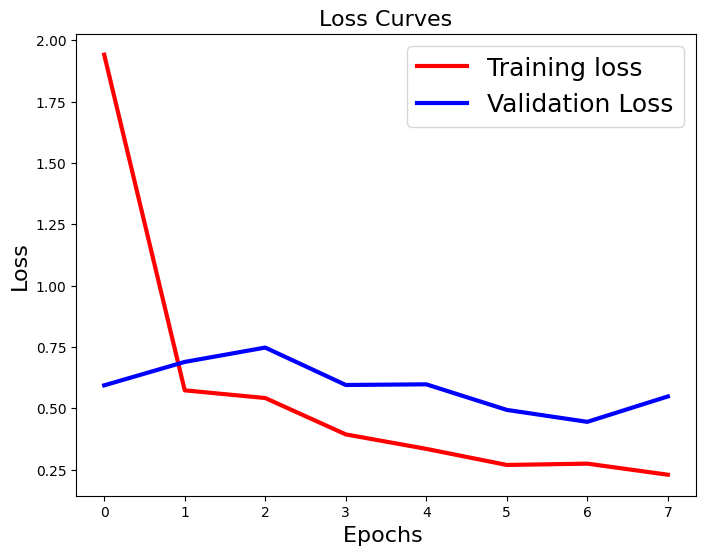

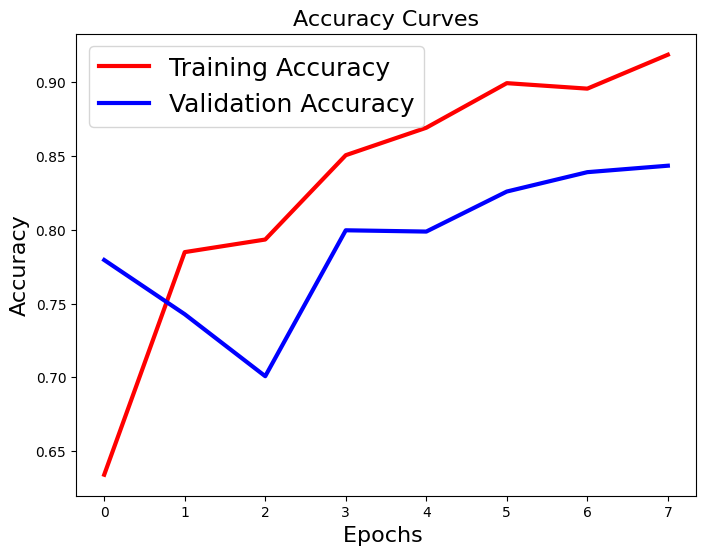

In [38]:
# Plot the Loss Curves for the fully connected neural network model
plt.figure(figsize=[8,6])
plt.plot(history_fcn.history['loss'], 'r', linewidth=3.0)         # Training loss
plt.plot(history_fcn.history['val_loss'], 'b', linewidth=3.0)     # Validation loss
plt.legend(['Training loss', 'Validation Loss'], fontsize=18)      # Legend
plt.xlabel('Epochs', fontsize=16)                                   # X-axis label
plt.ylabel('Loss', fontsize=16)                                     # Y-axis label
plt.title('Loss Curves', fontsize=16)                               # Title
plt.show()                                                          # Display the plot

# Plot the Accuracy Curves for the fully connected neural network model
plt.figure(figsize=[8,6])
plt.plot(history_fcn.history['accuracy'], 'r', linewidth=3.0)       # Training accuracy
plt.plot(history_fcn.history['val_accuracy'], 'b', linewidth=3.0)   # Validation accuracy
plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=18)# Legend
plt.xlabel('Epochs', fontsize=16)                                   # X-axis label
plt.ylabel('Accuracy', fontsize=16)                                 # Y-axis label
plt.title('Accuracy Curves', fontsize=16)                           # Title
plt.show()                                                          # Display the plot


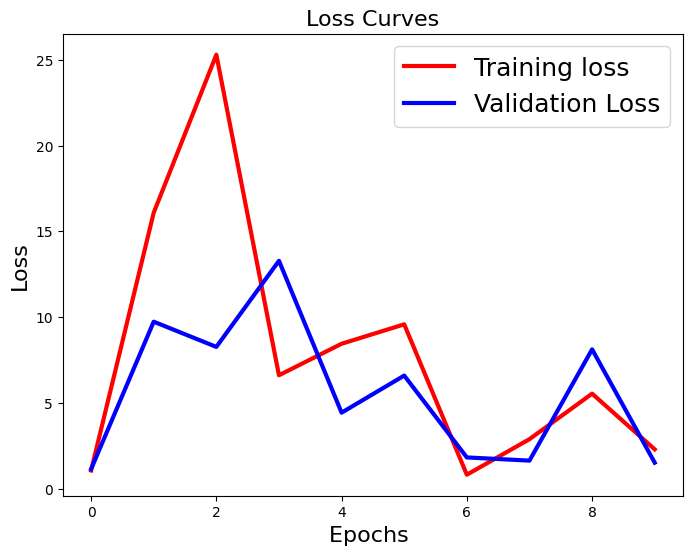

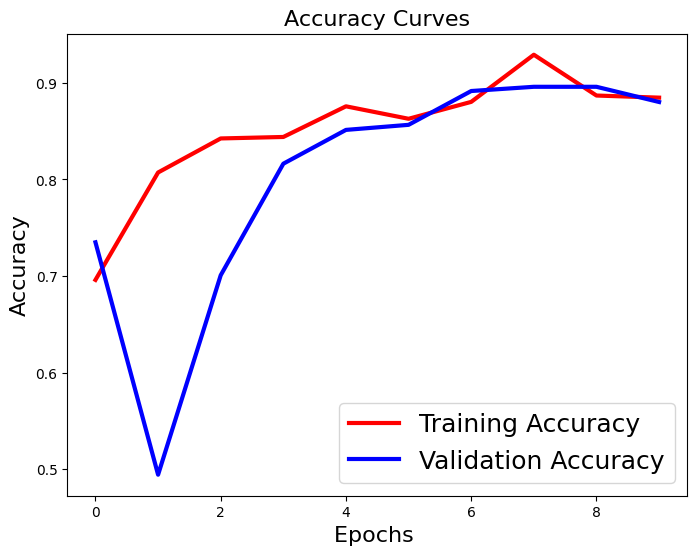

In [17]:
#Plot the Loss Curves for cnn

plt.figure(figsize=[8,6])
plt.plot(history_cnn.history['loss'],'r',linewidth=3.0)         # Training loss
plt.plot(history_cnn.history['val_loss'],'b',linewidth=3.0)     # Validation loss
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)    # Legend
plt.xlabel('Epochs',fontsize=16)                               # X-axis label
plt.ylabel('Loss',fontsize=16)                                 # Y-axis label
plt.title('Loss Curves',fontsize=16)                            # Title
plt.show()                                                      # Display the plot

# Plot the Accuracy Curves for the CNN model
plt.figure(figsize=[8,6])
plt.plot(history_cnn.history['accuracy'],'r',linewidth=3.0)     # Training accuracy
plt.plot(history_cnn.history['val_accuracy'],'b',linewidth=3.0) # Validation accuracy
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18) # Legend
plt.xlabel('Epochs',fontsize=16)                               # X-axis label
plt.ylabel('Accuracy',fontsize=16)                             # Y-axis label
plt.title('Accuracy Curves',fontsize=16)                        # Title
plt.show()                                                      # Display the plot

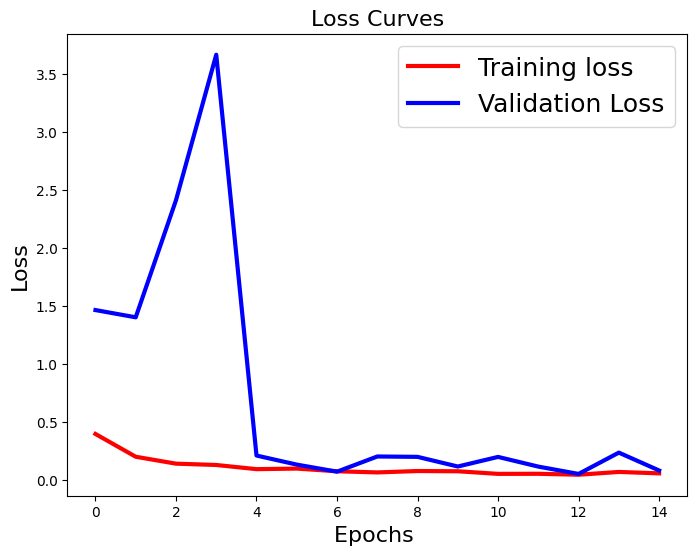

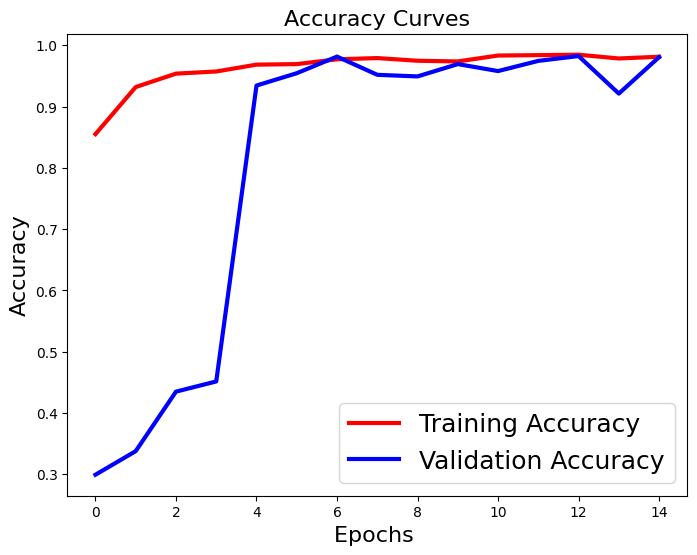

In [20]:
#Plot the Loss Curves for transfer learning

# Plot the Loss Curves for the transfer learning model
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)         # Training loss
plt.plot(history.history['val_loss'],'b',linewidth=3.0)     # Validation loss
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)    # Legend
plt.xlabel('Epochs',fontsize=16)                               # X-axis label
plt.ylabel('Loss',fontsize=16)                                 # Y-axis label
plt.title('Loss Curves',fontsize=16)                            # Title
plt.show()                                                      # Display the plot

# Plot the Accuracy Curves for the transfer learning model
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)     # Training accuracy
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0) # Validation accuracy
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18) # Legend
plt.xlabel('Epochs',fontsize=16)                               # X-axis label
plt.ylabel('Accuracy',fontsize=16)                             # Y-axis label
plt.title('Accuracy Curves',fontsize=16)                        # Title
plt.show()        

In [33]:
import seaborn as sns

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       300
           1       0.98      0.91      0.95       306
           2       0.98      1.00      0.99       405
           3       0.99      0.99      0.99       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311



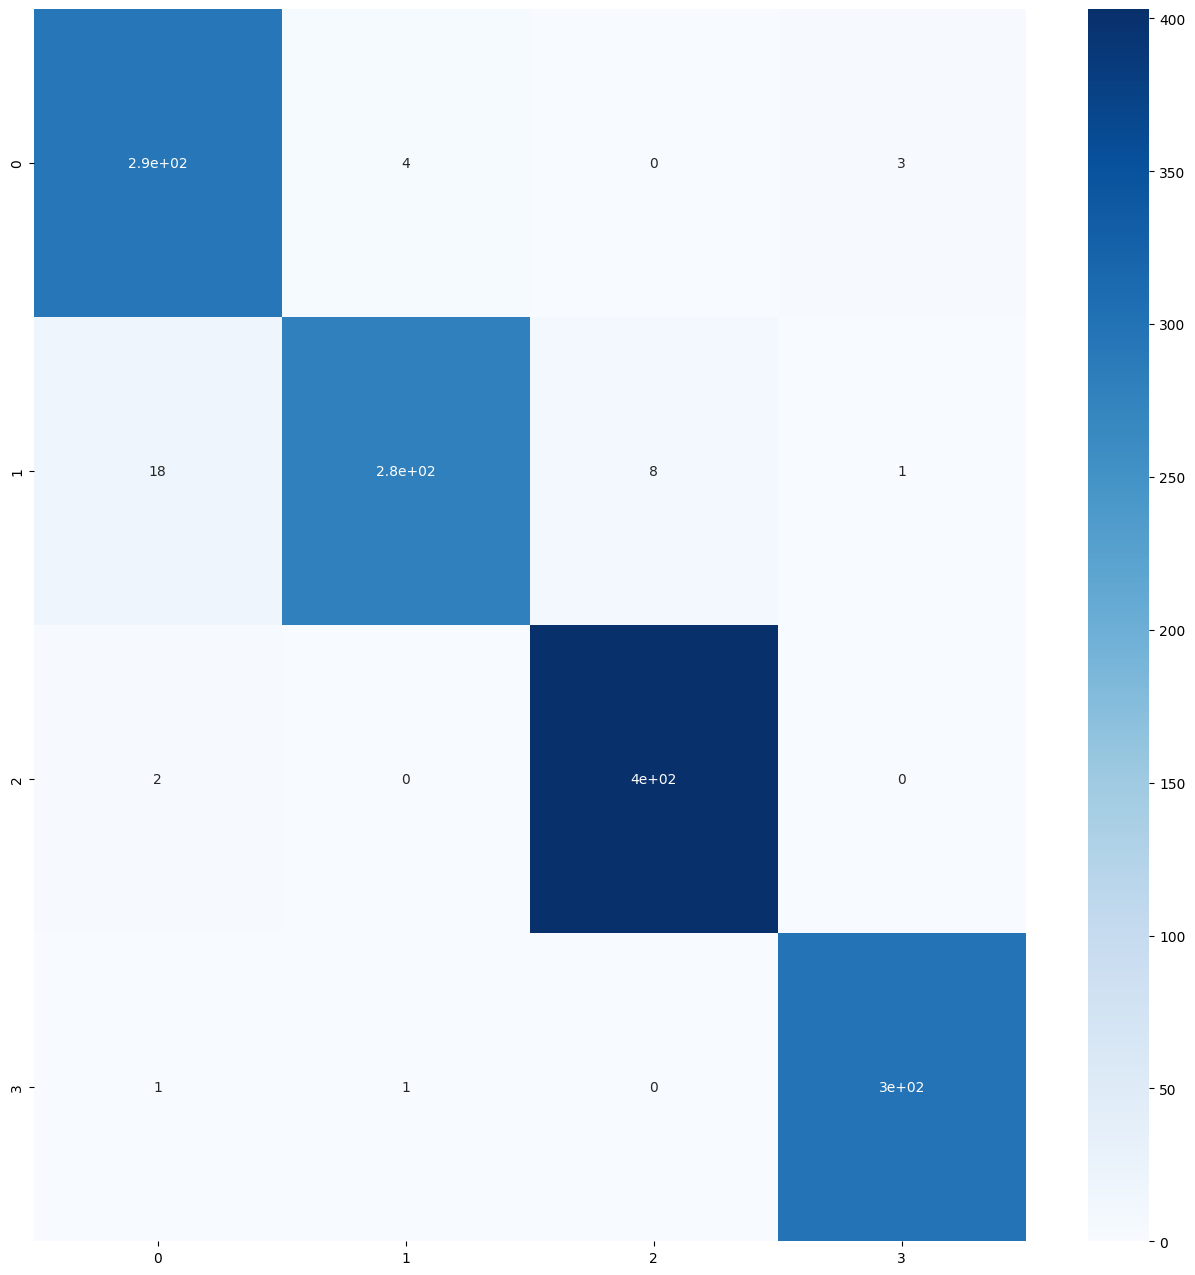

In [34]:
#for transfer learning
# Predict classes for the test data using the transfer learning model
predicted_classes = np.argmax(model.predict(x_test), axis=1)

# Compute the confusion matrix
confusionmatrix = confusion_matrix(np.argmax(y_test, axis=1), predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(16, 16))
sns.heatmap(confusionmatrix, cmap='Blues', annot=True, cbar=True)  # Heatmap with annotations
plt.xlabel('Predicted Label')  # X-axis label
plt.ylabel('True Label')       # Y-axis label
plt.show()                     # Display the plot

# Print the classification report
print(classification_report(np.argmax(y_test, axis=1), predicted_classes))

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


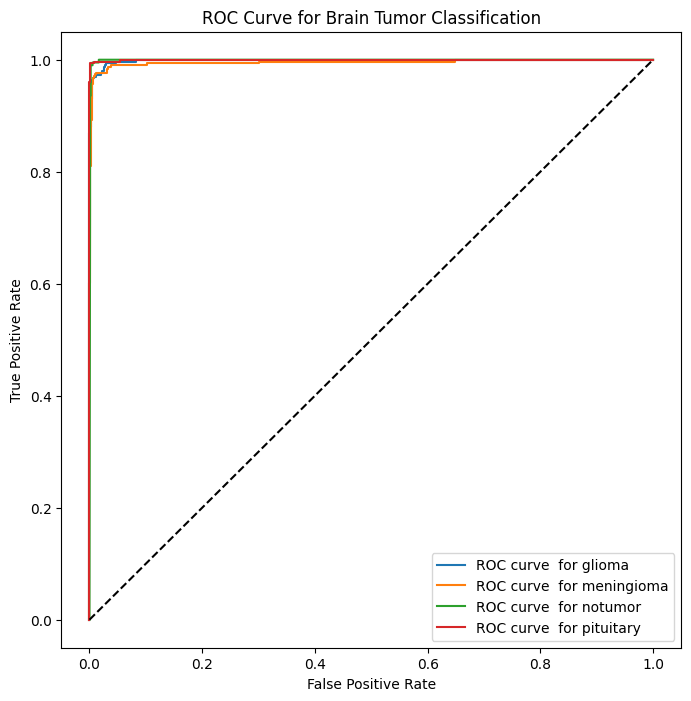

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate the probabilities for each class using the transfer learning model
y_probs = model.predict(x_test)

# Calculate the ROC curve for each class
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area under the ROC curve
for i in range(len(labels)):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_probs[:, i])  # Compute ROC curve
    roc_auc[i] = roc_auc_score(y_test[:, i], y_probs[:, i])     # Compute AUC

# Plot ROC curve for each class
plt.figure(figsize=(8, 8))
for i in range(len(labels)):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve for {labels[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Brain Tumor Classification')
plt.legend(loc='lower right')
plt.show()

2024-05-11 08:15:11.116271: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 0: 3.94275, expected 3.24734
2024-05-11 08:15:11.116334: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 1: 4.4544, expected 3.75899
2024-05-11 08:15:11.116343: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2: 5.57826, expected 4.88285
2024-05-11 08:15:11.116370: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 3: 5.19474, expected 4.49933
2024-05-11 08:15:11.116379: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 4: 5.51876, expected 4.82335
2024-05-11 08:15:11.116387: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 5: 5.42651, expected 4.7311
2024-05-11 08:15:11.116395: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 7: 4.30452, expected 3.6091
2024-05-11 08:15:11.116403: E external/local_xla/xla/servi

39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

2024-05-11 08:15:13.745681: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 0: 3.52853, expected 2.92353
2024-05-11 08:15:13.745746: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 1: 4.77244, expected 4.16744
2024-05-11 08:15:13.745756: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 2: 4.32907, expected 3.72407
2024-05-11 08:15:13.745763: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 3: 4.49204, expected 3.88704
2024-05-11 08:15:13.745774: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 5: 3.91797, expected 3.31297
2024-05-11 08:15:13.745781: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 7: 4.11087, expected 3.50587
2024-05-11 08:15:13.745788: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 8: 3.81469, expected 3.20969
2024-05-11 08:15:13.745796: E external/local_xla/xla/se

41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step
              precision    recall  f1-score   support

           0       0.97      0.78      0.87       300
           1       0.79      0.89      0.83       306
           2       0.94      0.99      0.96       405
           3       0.97      0.96      0.96       300

    accuracy                           0.91      1311
   macro avg       0.92      0.90      0.91      1311
weighted avg       0.92      0.91      0.91      1311



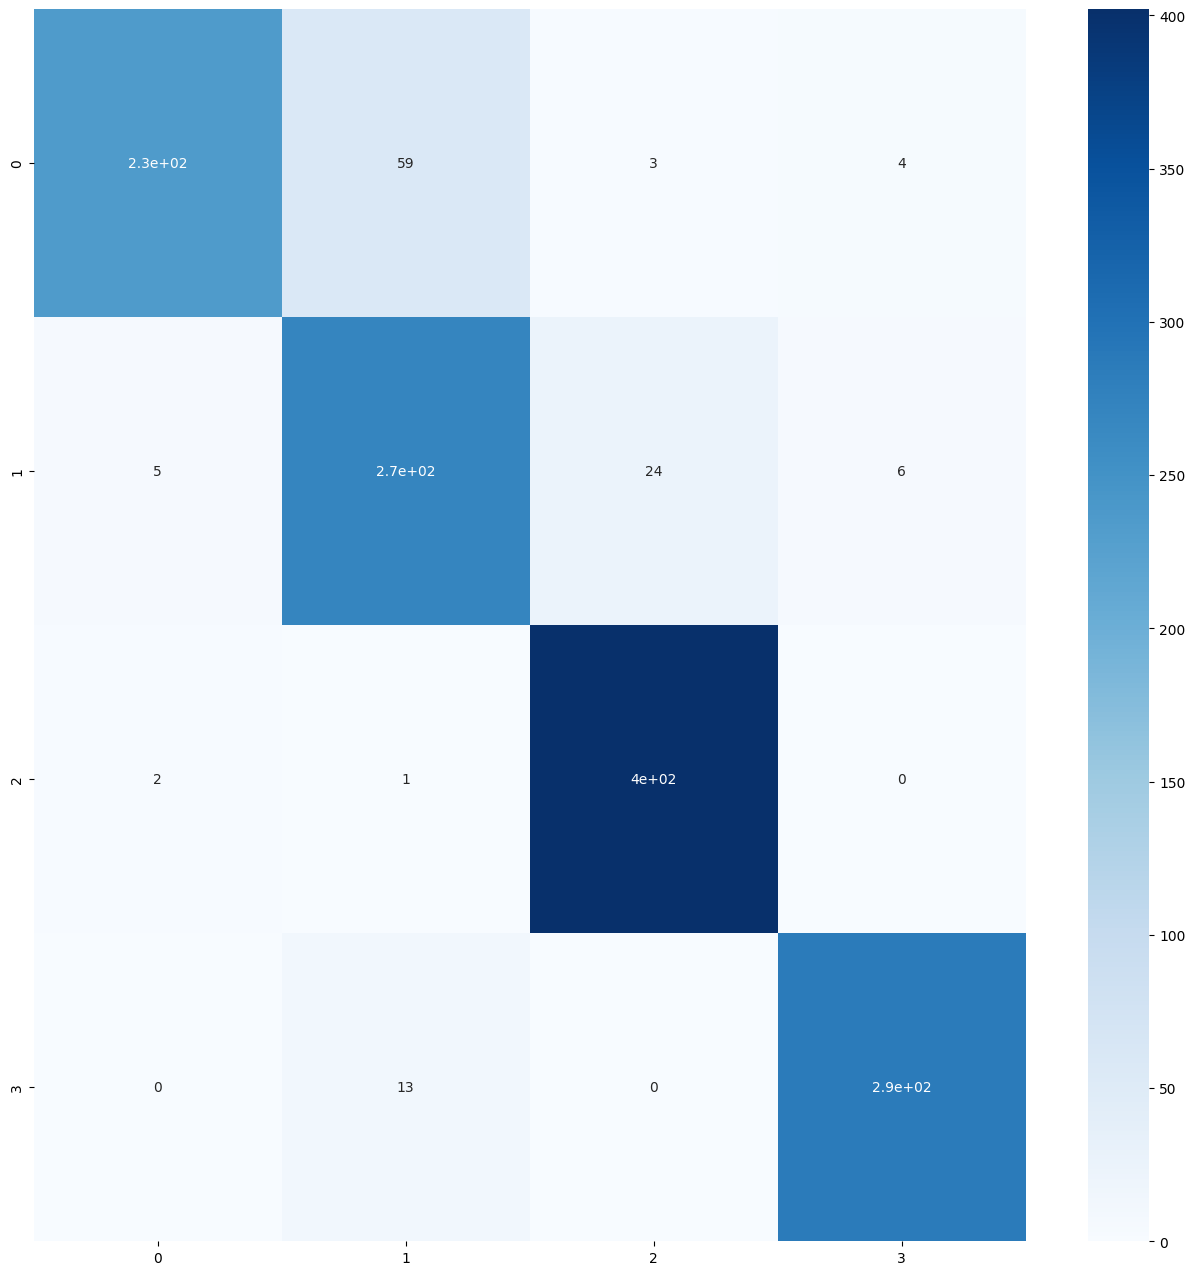

In [35]:
# Predict classes for the test data using the CNN model
predicted_classes = np.argmax(model_cnn.predict(x_test), axis=1)

# Compute the confusion matrix
confusionmatrix = confusion_matrix(np.argmax(y_test, axis=1), predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(16, 16))
sns.heatmap(confusionmatrix, cmap='Blues', annot=True, cbar=True)  # Heatmap with annotations
plt.xlabel('Predicted Label')  # X-axis label
plt.ylabel('True Label')       # Y-axis label
plt.show()                     # Display the plot

# Print the classification report
print(classification_report(np.argmax(y_test, axis=1), predicted_classes))

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


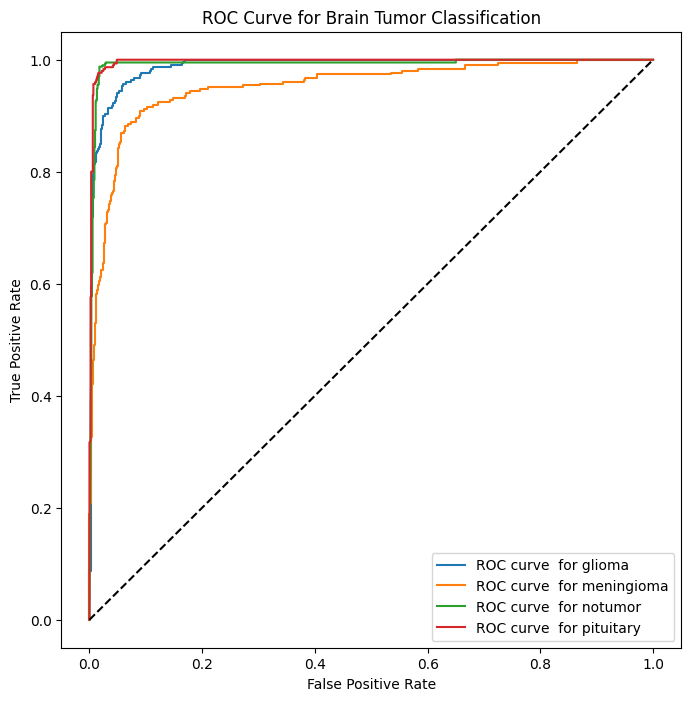

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate the probabilities for each class using the CNN model
y_probs = model_cnn.predict(x_test)

# Calculate the ROC curve for each class
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area under the ROC curve
for i in range(len(labels)):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_probs[:, i])  # Compute ROC curve
    roc_auc[i] = roc_auc_score(y_test[:, i], y_probs[:, i])     # Compute AUC

# Plot ROC curve for each class
plt.figure(figsize=(8, 8))
for i in range(len(labels)):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve for {labels[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Brain Tumor Classification')
plt.legend(loc='lower right')
plt.show()


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

           0       0.71      0.82      0.76       300
           1       0.68      0.48      0.56       306
           2       0.86      0.93      0.89       405
           3       0.90      0.94      0.92       300

    accuracy                           0.80      1311
   macro avg       0.79      0.79      0.78      1311
weighted avg       0.79      0.80      0.79      1311



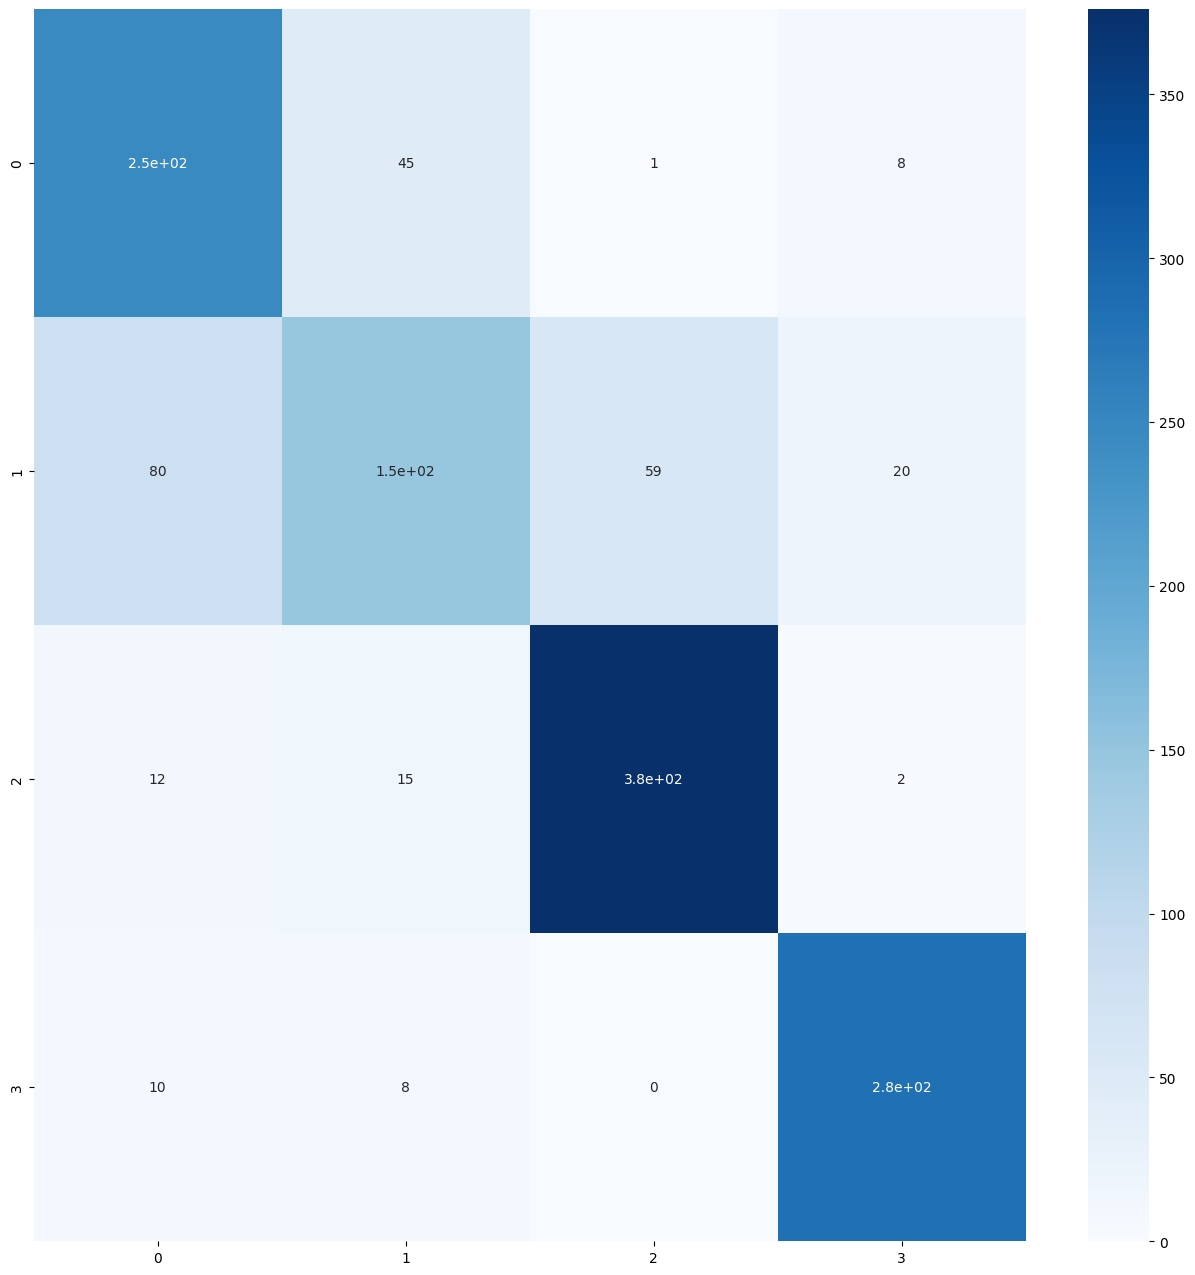

In [37]:
# Predict classes for the test data using the fully connected neural network model
predicted_classes = np.argmax(fully_connected_model.predict(x_test), axis=1)

# Compute the confusion matrix
confusionmatrix = confusion_matrix(np.argmax(y_test, axis=1), predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(16, 16))
sns.heatmap(confusionmatrix, cmap='Blues', annot=True, cbar=True)  # Heatmap with annotations
plt.xlabel('Predicted Label')  # X-axis label
plt.ylabel('True Label')       # Y-axis label
plt.show()                     # Display the plot

# Print the classification report
print(classification_report(np.argmax(y_test, axis=1), predicted_classes))

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


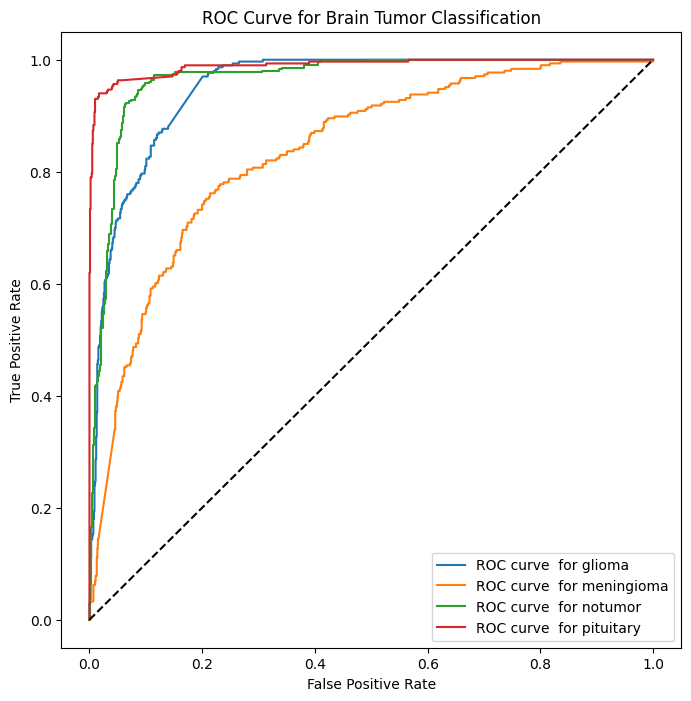

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate the probabilities for each class using the fully connected neural network model
y_probs = fully_connected_model.predict(x_test)

# Calculate the ROC curve for each class
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area under the ROC curve
for i in range(len(labels)):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_probs[:, i])  # Compute ROC curve
    roc_auc[i] = roc_auc_score(y_test[:, i], y_probs[:, i])     # Compute AUC

# Plot ROC curve for each class
plt.figure(figsize=(8, 8))
for i in range(len(labels)):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve for {labels[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Brain Tumor Classification')
plt.legend(loc='lower right')
plt.show()


In [50]:
# Evaluate the transfer learning model on the test data
loss, acc = model.evaluate(x_test, y_test)

# Print the loss and accuracy metrics
print("Test Loss:", loss)
print("Test Accuracy:", acc)


NameError: name 'model' is not defined

In [31]:
# Evaluate the CNN model on the test data
loss, acc = model_cnn.evaluate(x_test, y_test)

# Print the loss and accuracy metrics
print("Test Loss:", loss)
print("Test Accuracy:", acc)


10/41 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8953 - loss: 0.4435

W0000 00:00:1715022832.811220     119 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9199 - loss: 0.3828


W0000 00:00:1715022833.840677     119 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [51]:
# Evaluate the fully connected neural network model on the test data
loss, acc = fully_connected_model.evaluate(x_test, y_test)

# Print the loss and accuracy metrics
print("Test Loss:", loss)
print("Test Accuracy:", acc)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7927 - loss: 0.7222


**Prediction of image**

In [19]:
def load_and_pred_image(filename, img_shape=200):
    # Read in the image
    img = tf.io.read_file(filename)
    # Decode the read file into tensor
    img = tf.image.decode_image(img, channels=3)  # Assuming RGB images
    # Resize the image
    img = tf.image.resize(img, size=[img_shape, img_shape])
    # Rescale the image
    img = img / 255.0
    return img


In [53]:
# Load and preprocess the image
giloma = load_and_pred_image("/kaggle/input/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0000.jpg")

# Add an extra dimension to match the model input shape
giloma = tf.expand_dims(giloma, axis=0)

# Make predictions using the fully connected neural network model
pred = fully_connected_model.predict(giloma)

# Print the predicted probabilities for each class
print("Predicted probabilities:", pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


array([[0.10985076, 0.8608592 , 0.02824686, 0.00104318]], dtype=float32)

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import pathlib
import random
import numpy as np
# Specify the path to the data directory
data_dir = pathlib.Path("/kaggle/input/brain-tumor-mri-dataset/Training")

# Create a list of class names (assuming the first four directories in data_dir are the classes)
class_names = np.array(sorted([item.name for item in data_dir.glob("*")]))
class_names = class_names[:4]  # Considering only the first four classes

print("Class Names:", class_names)

['glioma' 'meningioma' 'notumor' 'pituitary']


In [21]:
def pred_and_plot(model, filename, class_names=class_names):
    # Load and preprocess the target image
    img = load_and_pred_image(filename)
    
    # Make a prediction
    pred = model.predict(tf.expand_dims(img, axis=0))

    # Adding logic for multiclass to make 1 array
    if len(pred[0]) > 1:
        pred_class = class_names[tf.argmax(pred[0])]
    else:
        pred_class = class_names[int(tf.round(pred[0]))]

    # Plot the image and predicted class
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis(False)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


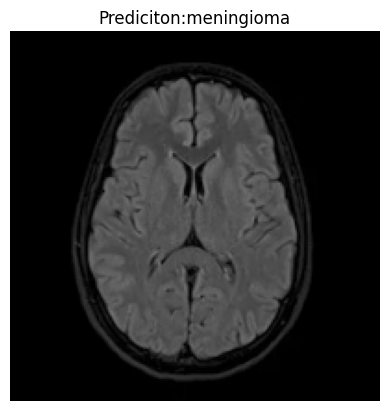

In [41]:
# Make predictions and plot the result using the fully connected neural network model
pred_and_plot(fully_connected_model, "/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-noTr_0002.jpg")


In [40]:
model_cnn.save("model_cnn.h5")

In [58]:
fully_connected_model.save('fully_connected_model.h5')

In [29]:
model.save('higest_accuracy_tumor_model.h5')